# Differencing Filter 적합성 체크

## 배경

현재 `debiased_whittle.py`에서 사용하는 공간 differencing 필터:

$$Z(i,j) = -2X(i,j) + X(i+1,j) + X(i,j+1)$$

즉 **`[-2, 1; 1, 0]`** (2×2 convolution kernel). 이건 두 방향의 1차 차분의 합:

$$Z(i,j) = \underbrace{[X(i+1,j) - X(i,j)]}_{\Delta_{\text{lat}}} + \underbrace{[X(i,j+1) - X(i,j)]}_{\Delta_{\text{lon}}}$$

## 이 노트북에서 확인하는 것

1. **Block 1** — 필터 주파수 응답 비교: `[-2,1;1,0]` vs `[-1,1;1,-1]` vs no filter  
2. **Block 2** — 데이터 공간 추세 체크: differencing이 실제로 필요한가?  
3. **Block 3** — Raw vs 필터 적용 후 데이터 비교 (분산, 공간 구조)  
4. **Block 4** — 대안 방법들 비교

In [2]:
import sys
import warnings
import numpy as np
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from scipy.signal import periodogram

warnings.filterwarnings('ignore')

sys.path.append("/Users/joonwonlee/Documents/GEMS_TCO-1/src")
from GEMS_TCO import configuration as config
from GEMS_TCO import debiased_whittle as debiased_whittle
from GEMS_TCO.data_loader import load_data_dynamic_processed

OUT_DIR = Path("/Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/seasonal_ar/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Setup done.")

Setup done.


---
## Block 1 — 필터 주파수 응답 비교 (데이터 불필요)

각 필터의 **전달함수** $H(\omega_1, \omega_2)$와 **파워 스펙트럼** $|H(\omega_1, \omega_2)|^2$.

| 필터 | 커널 | 수식 | $|H|^2$ (저주파) |
|---|---|---|---|
| Old (현재) | `[-2,1;1,0]` | $\Delta_{\text{lat}} X + \Delta_{\text{lon}} X$ | $(\omega_1 + \omega_2)^2$ |
| New (separable) | `[-1,1;1,-1]` | $\Delta_{\text{lat}}(\Delta_{\text{lon}} X)$ | $\omega_1^2 \cdot \omega_2^2$ |
| Lat only | `[-1,1]` | $\Delta_{\text{lat}} X$ | $\omega_1^2$ |
| No filter | identity | $X$ | $1$ (flat) |

**핵심 차이**:
- Old: $|H|^2 \approx (\omega_1+\omega_2)^2$ → 방향성 있는 저주파 억제 (대각선 $\omega_1+\omega_2=0$ 방향만 살아남)
- New: $|H|^2 \approx \omega_1^2 \omega_2^2$ → $\omega_1=0$ 또는 $\omega_2=0$ 방향 모두 제거 (더 강한 low-freq 억제)

Font 'default' does not have a glyph for '\ud544' [U+d544], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ud130' [U+d130], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uc8fc' [U+c8fc], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ud30c' [U+d30c], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uc218' [U+c218], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uc751' [U+c751], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ub2f5' [U+b2f5], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uc800' [U+c800], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uc5d0' [U+c5d0], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uc11c' [U+c11c], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uc5bc' [U+c5bc], 

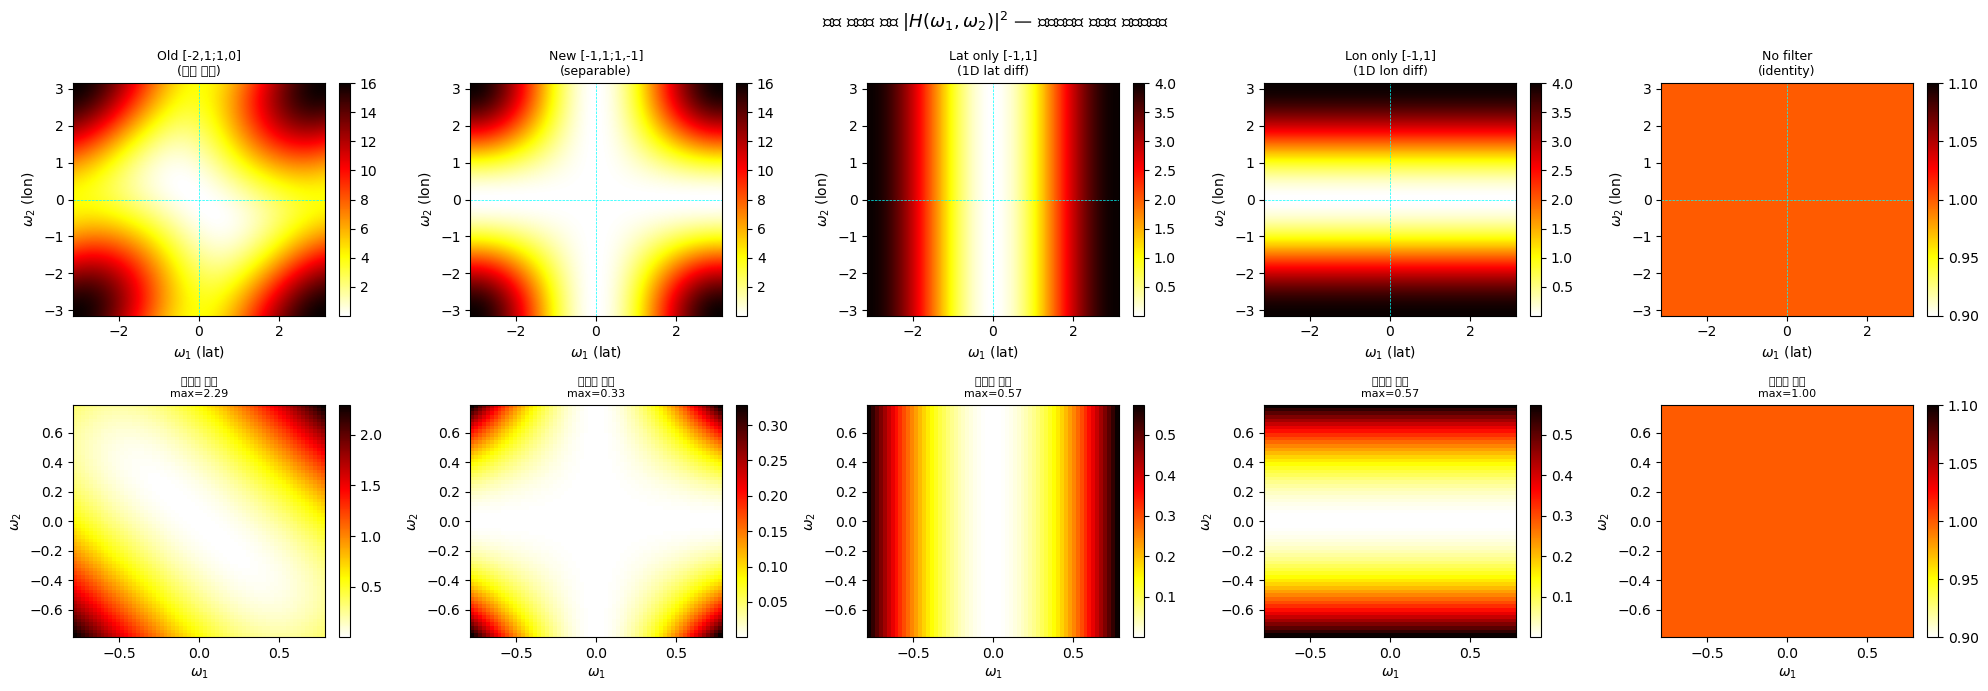

Saved: diff_filter_frequency_response.png


In [3]:
# ── Block 1: 2D 주파수 응답 계산 및 시각화 ────────────────────────────────────

N = 256   # frequency grid resolution
w1 = np.linspace(-np.pi, np.pi, N)
w2 = np.linspace(-np.pi, np.pi, N)
W1, W2 = np.meshgrid(w1, w2)

# 전달함수 H(ω1, ω2) = Σ h(k,l) * exp(i*(k*ω1 + l*ω2))
# kernel [h(0,0), h(1,0); h(0,1), h(1,1)] → H = h00 + h10*e^{iω1} + h01*e^{iω2} + h11*e^{i(ω1+ω2)}

def transfer_fn(h00, h10, h01, h11=0.0):
    return (h00
            + h10 * np.exp(1j * W1)
            + h01 * np.exp(1j * W2)
            + h11 * np.exp(1j * (W1 + W2)))

filters = {
    'Old [-2,1;1,0]\n(현재 사용)': transfer_fn(-2, 1, 1, 0),
    'New [-1,1;1,-1]\n(separable)': transfer_fn(-1, 1, 1, -1),
    'Lat only [-1,1]\n(1D lat diff)': (np.exp(1j * W1) - 1),
    'Lon only [-1,1]\n(1D lon diff)': (np.exp(1j * W2) - 1),
    'No filter\n(identity)':  np.ones_like(W1, dtype=complex),
}

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
fig.suptitle('필터 주파수 응답 $|H(\\omega_1, \\omega_2)|^2$ — 저주파에서 얼마나 억제하는가', fontsize=13)

for col, (name, H) in enumerate(filters.items()):
    power = np.abs(H) ** 2

    # 상단: 전체 범위 heatmap
    ax = axes[0, col]
    im = ax.imshow(power, origin='lower', extent=[-np.pi, np.pi, -np.pi, np.pi],
                   cmap='hot_r', aspect='auto')
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('$\\omega_1$ (lat)'); ax.set_ylabel('$\\omega_2$ (lon)')
    ax.axhline(0, ls='--', color='cyan', lw=0.5)
    ax.axvline(0, ls='--', color='cyan', lw=0.5)
    plt.colorbar(im, ax=ax, fraction=0.046)

    # 하단: 저주파 확대 (±π/4)
    ax2 = axes[1, col]
    zoom = N // 8
    center = N // 2
    power_zoom = power[center-zoom:center+zoom, center-zoom:center+zoom]
    im2 = ax2.imshow(power_zoom, origin='lower',
                     extent=[-np.pi/4, np.pi/4, -np.pi/4, np.pi/4],
                     cmap='hot_r', aspect='auto')
    ax2.set_title(f'저주파 확대\nmax={power_zoom.max():.2f}', fontsize=8)
    ax2.set_xlabel('$\\omega_1$'); ax2.set_ylabel('$\\omega_2$')
    plt.colorbar(im2, ax=ax2, fraction=0.046)

plt.tight_layout()
plt.savefig(OUT_DIR / 'diff_filter_frequency_response.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: diff_filter_frequency_response.png")

Font 'default' does not have a glyph for '\ub2e8' [U+b2e8], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uba74' [U+ba74], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ub2e8' [U+b2e8], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uba74' [U+ba74], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ub2e8' [U+b2e8], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uba74' [U+ba74], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ub2e8' [U+b2e8], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uba74' [U+ba74], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ub2e8' [U+b2e8], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uba74' [U+ba74], substituting with a dummy symbol.


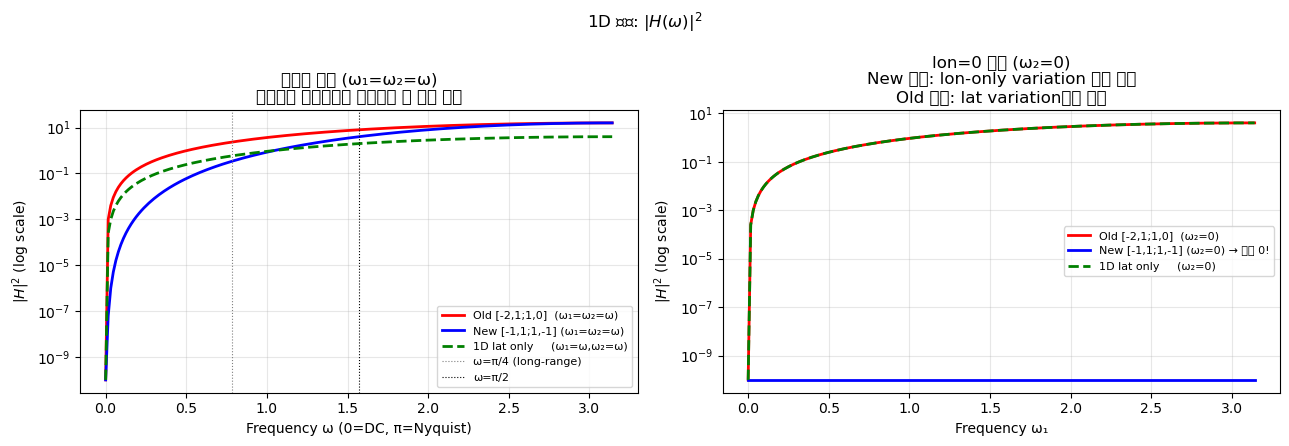


필터 특성 요약:
필터                     |H|² at ω=0.1      |H|² at ω=π/2      |H|² at ω=π  low-freq 행동
Old [-2,1;1,0]         0.0359             7.9369             16.0000      O(ω²)
New [-1,1;1,-1]        0.0001             3.9371             16.0000      O(ω⁴)
1D lat only            0.0090             1.9842             4.0000       O(ω²)


In [4]:
# ── Block 1b: 1D 단면 비교 (ω1 = ω2 = ω 대각선) ──────────────────────────────

omega = np.linspace(0, np.pi, 200)

# |H(ω,ω)|² for each filter along the diagonal ω1=ω2=ω
H_old_diag  = np.abs(-2 + np.exp(1j*omega) + np.exp(1j*omega)) ** 2   # = |2(e^{iω}-1)|²
H_new_diag  = np.abs((-1 + np.exp(1j*omega)) * (1 - np.exp(1j*omega))) ** 2  # |1-e^{iω}|^4
H_lat_diag  = np.abs(np.exp(1j*omega) - 1) ** 2
H_none_diag = np.ones_like(omega)

# Along ω2=0 axis (ω1 varies)
H_old_lon0  = np.abs(-2 + np.exp(1j*omega) + 1) ** 2    # = |e^{iω}-1|²
H_new_lon0  = np.abs((-1 + np.exp(1j*omega)) * (1 - 1)) ** 2  # = 0 for all ω!
H_lat_lon0  = np.abs(np.exp(1j*omega) - 1) ** 2

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('1D 단면: $|H(\\omega)|^2$', fontsize=12)

ax = axes[0]
ax.semilogy(omega, H_old_diag + 1e-10,  label='Old [-2,1;1,0]  (ω₁=ω₂=ω)', color='red',    lw=2)
ax.semilogy(omega, H_new_diag + 1e-10,  label='New [-1,1;1,-1] (ω₁=ω₂=ω)', color='blue',   lw=2)
ax.semilogy(omega, H_lat_diag + 1e-10,  label='1D lat only     (ω₁=ω,ω₂=ω)', color='green', lw=2, ls='--')
ax.axvline(np.pi/4, ls=':', color='gray', lw=0.8, label='ω=π/4 (long-range)')
ax.axvline(np.pi/2, ls=':', color='black', lw=0.8, label='ω=π/2')
ax.set_xlabel('Frequency ω (0=DC, π=Nyquist)')
ax.set_ylabel('$|H|^2$ (log scale)')
ax.set_title('대각선 방향 (ω₁=ω₂=ω)\n슬로프가 가파를수록 저주파를 더 많이 억제')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(omega, H_old_lon0 + 1e-10,  label='Old [-2,1;1,0]  (ω₂=0)', color='red',   lw=2)
ax.semilogy(omega, H_new_lon0 + 1e-10,  label='New [-1,1;1,-1] (ω₂=0) → 항상 0!', color='blue', lw=2)
ax.semilogy(omega, H_lat_lon0 + 1e-10,  label='1D lat only     (ω₂=0)', color='green', lw=2, ls='--')
ax.set_xlabel('Frequency ω₁')
ax.set_ylabel('$|H|^2$ (log scale)')
ax.set_title('lon=0 방향 (ω₂=0)\nNew 필터: lon-only variation 완전 제거\nOld 필터: lat variation만큼 통과')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'diff_filter_1d_slice.png', dpi=120, bbox_inches='tight')
plt.show()

# 요약 테이블
print('\n필터 특성 요약:')
print(f'{"필터":<22} {"|H|² at ω=0.1":<18} {"|H|² at ω=π/2":<18} {"|H|² at ω=π":<12} {"low-freq 행동"}')
for label, vals in [
    ('Old [-2,1;1,0]',  H_old_diag),
    ('New [-1,1;1,-1]', H_new_diag),
    ('1D lat only',     H_lat_diag),
]:
    idx01  = np.argmin(np.abs(omega - 0.1))
    idxpi2 = np.argmin(np.abs(omega - np.pi/2))
    behavior = 'O(ω²)' if label.startswith('1D') else ('O(ω²)' if label.startswith('Old') else 'O(ω⁴)')
    print(f'{label:<22} {vals[idx01]:<18.4f} {vals[idxpi2]:<18.4f} {vals[-1]:<12.4f} {behavior}')

---
## Block 2 — 데이터 공간 추세 체크

Differencing이 필요한 이유: Whittle likelihood는 **정상 과정(stationary process)**을 가정함.  
데이터에 공간 추세가 있으면 비정상 → differencing으로 근사 정상화.

**체크 방법**:
1. Raw 공간 필드 시각화 — 대규모 gradient 있나?
2. 방향별 variogram $\hat{\gamma}(h) = \frac{1}{2N}\sum [Z(s+h)-Z(s)]^2$ — 거리에 따라 계속 증가하면 비정상
3. 행별/열별 평균 — lat/lon 방향 추세 확인

In [5]:
# ── Block 2: 데이터 로딩 (gpu_dw_fit_dynamic_grid_040226.ipynb 와 동일) ────────

lat_lon_resolution = [1, 1]
mm_cond_number = 8
years = ['2022']
month_range = [7]
lat_range_input = [-3, 2]
lon_range_input = [121, 131]

data_load_instance = load_data_dynamic_processed(config.mac_data_load_path)

df_map, ord_mm, nns_map, monthly_mean = data_load_instance.load_maxmin_ordered_data_bymonthyear(
    lat_lon_resolution=lat_lon_resolution,
    mm_cond_number=mm_cond_number,
    years_=years,
    months_=month_range,
    lat_range=lat_range_input,
    lon_range=lon_range_input,
    is_whittle=True
)

SLOTS_PER_DAY = 8
sorted_keys   = sorted(df_map.keys())
n_total_slots = len(sorted_keys)
n_days        = n_total_slots // SLOTS_PER_DAY
print(f"Loaded: {n_days} days, {SLOTS_PER_DAY} slots/day")

# Day 0, slot 0 의 raw tensor 추출
DAY_IDX  = 0
SLOT_IDX = 3   # 정오 근처 슬롯
key = sorted_keys[DAY_IDX * SLOTS_PER_DAY + SLOT_IDX]
raw_tensor = df_map[key]
print(f"Sample key: {key}, shape: {raw_tensor.shape}")
print(raw_tensor.head())

--- Global Monthly Mean for 2022-7: 250.6500 ---
Loaded: 30 days, 8 slots/day
Sample key: 2022_07_y22m07day01_hm03:48, shape: (18126, 6)
   Latitude  Longitude  ColumnAmountO3  Hours_elapsed  Source_Latitude  \
0       2.0    131.000       246.06271       460179.8         1.979777   
1       2.0    130.937       246.86876       460179.8         1.979783   
2       2.0    130.874       245.69093       460179.8         1.979856   
3       2.0    130.811       246.60234       460179.8         1.979928   
4       2.0    130.748       246.37227       460179.8         1.980109   

   Source_Longitude  
0         130.97142  
1         130.90932  
2         130.84715  
3         130.78496  
4         130.72284  


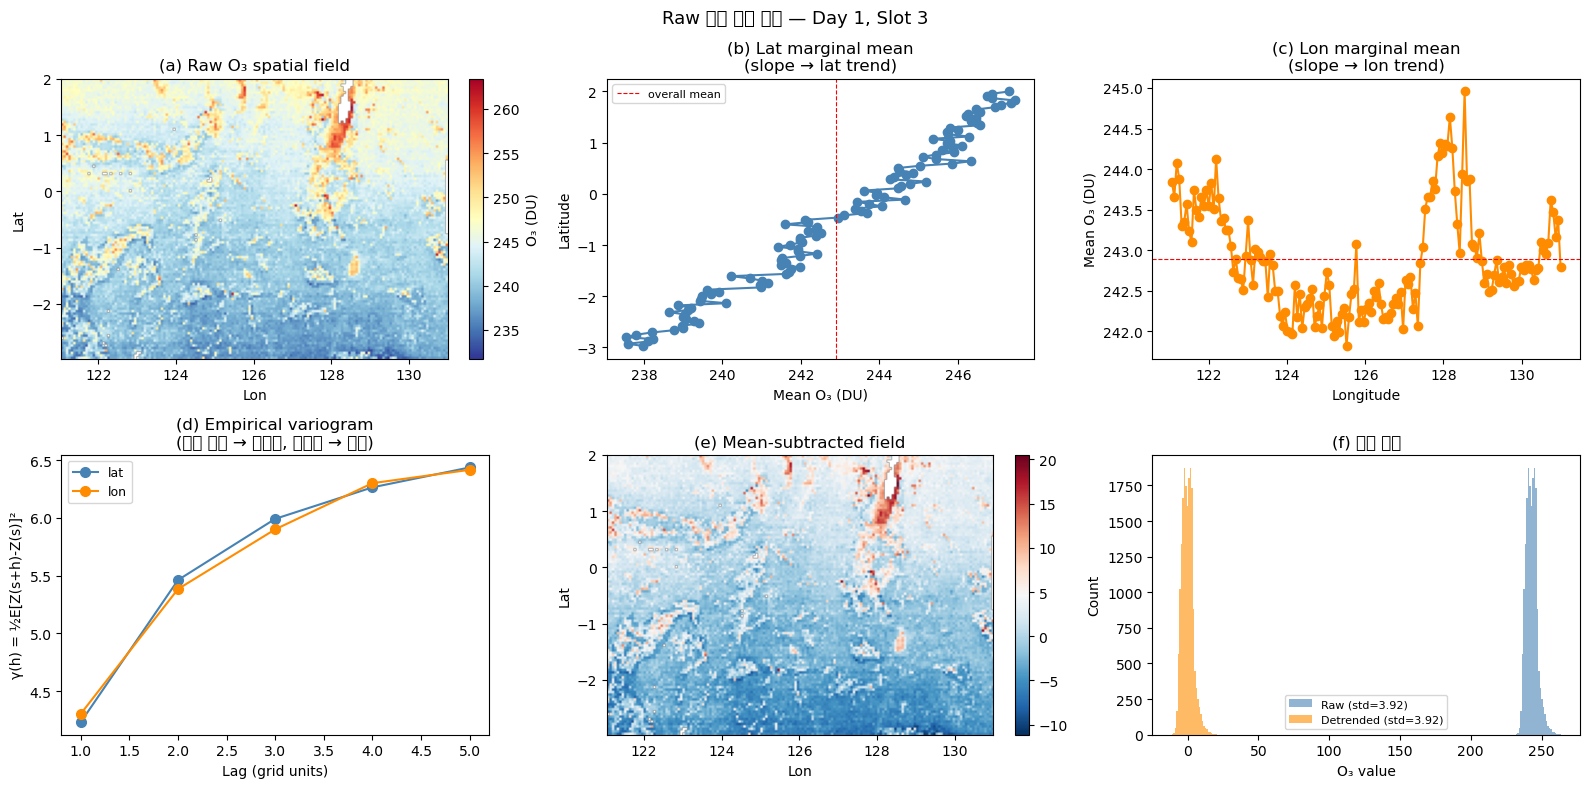


Raw field:
  mean=242.88, std=3.92
  lat range: -3.0 ~ 2.0
  lon range: 121.0 ~ 131.0
  lat slope (DU/degree): 1.9207
  lon slope (DU/degree): -0.0042


In [6]:
# ── Block 2: Raw 공간 필드 시각화 + Variogram ──────────────────────────────────

def tensor_to_grid(tensor_df):
    """DataFrame (lat, lon, val, ...) → 2D numpy grid."""
    if hasattr(tensor_df, 'numpy'):
        arr = tensor_df.numpy() if not isinstance(tensor_df, np.ndarray) else tensor_df
    else:
        arr = tensor_df.values if hasattr(tensor_df, 'values') else np.array(tensor_df)
    
    lats = np.unique(arr[:, 0])
    lons = np.unique(arr[:, 1])
    grid = np.full((len(lats), len(lons)), np.nan)
    for row in arr:
        i = np.searchsorted(lats, row[0])
        j = np.searchsorted(lons, row[1])
        if i < len(lats) and j < len(lons):
            grid[i, j] = row[2]
    return grid, lats, lons


def empirical_variogram(grid, max_lag=5):
    """방향별 empirical variogram (lat / lon 방향)."""
    rows = []
    for direction in ['lat', 'lon']:
        for lag in range(1, max_lag + 1):
            if direction == 'lat':
                diff = grid[lag:, :] - grid[:-lag, :]
            else:
                diff = grid[:, lag:] - grid[:, :-lag]
            valid = diff[np.isfinite(diff)]
            if len(valid) > 0:
                gamma = 0.5 * np.mean(valid ** 2)
                rows.append({'direction': direction, 'lag': lag, 'gamma': gamma, 'n': len(valid)})
    return pd.DataFrame(rows)


grid_raw, lats, lons = tensor_to_grid(raw_tensor)
df_vario = empirical_variogram(grid_raw)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle(f'Raw 공간 필드 분석 — Day {DAY_IDX+1}, Slot {SLOT_IDX}', fontsize=13)

# (a) Raw spatial field
ax = axes[0, 0]
im = ax.imshow(grid_raw, origin='lower',
               extent=[lons.min(), lons.max(), lats.min(), lats.max()],
               aspect='auto', cmap='RdYlBu_r')
ax.set_title('(a) Raw O₃ spatial field')
ax.set_xlabel('Lon'); ax.set_ylabel('Lat')
plt.colorbar(im, ax=ax, fraction=0.046, label='O₃ (DU)')

# (b) Lat marginal mean (lon 평균)
ax = axes[0, 1]
lat_mean = np.nanmean(grid_raw, axis=1)
ax.plot(lat_mean, lats, 'o-', color='steelblue')
ax.set_xlabel('Mean O₃ (DU)'); ax.set_ylabel('Latitude')
ax.set_title('(b) Lat marginal mean\n(slope → lat trend)')
ax.axvline(np.nanmean(lat_mean), ls='--', color='red', lw=0.8, label='overall mean')
ax.legend(fontsize=8)

# (c) Lon marginal mean (lat 평균)
ax = axes[0, 2]
lon_mean = np.nanmean(grid_raw, axis=0)
ax.plot(lons, lon_mean, 'o-', color='darkorange')
ax.set_xlabel('Longitude'); ax.set_ylabel('Mean O₃ (DU)')
ax.set_title('(c) Lon marginal mean\n(slope → lon trend)')
ax.axhline(np.nanmean(lon_mean), ls='--', color='red', lw=0.8)

# (d) Empirical variogram
ax = axes[1, 0]
for direction, color in [('lat', 'steelblue'), ('lon', 'darkorange')]:
    sub = df_vario[df_vario['direction'] == direction]
    ax.plot(sub['lag'], sub['gamma'], 'o-', color=color, label=direction, markersize=7)
ax.set_xlabel('Lag (grid units)')
ax.set_ylabel('γ(h) = ½E[Z(s+h)-Z(s)]²')
ax.set_title('(d) Empirical variogram\n(계속 증가 → 비정상, 안정화 → 정상)')
ax.legend(fontsize=9)

# (e) Residual after mean subtraction
ax = axes[1, 1]
grid_detrended = grid_raw - np.nanmean(grid_raw)
im2 = ax.imshow(grid_detrended, origin='lower',
                extent=[lons.min(), lons.max(), lats.min(), lats.max()],
                aspect='auto', cmap='RdBu_r')
ax.set_title('(e) Mean-subtracted field')
ax.set_xlabel('Lon'); ax.set_ylabel('Lat')
plt.colorbar(im2, ax=ax, fraction=0.046)

# (f) Distribution comparison
ax = axes[1, 2]
raw_vals = grid_raw[np.isfinite(grid_raw)].flatten()
detr_vals = grid_detrended[np.isfinite(grid_detrended)].flatten()
ax.hist(raw_vals,  bins=30, alpha=0.6, color='steelblue',  label=f'Raw (std={raw_vals.std():.2f})')
ax.hist(detr_vals, bins=30, alpha=0.6, color='darkorange', label=f'Detrended (std={detr_vals.std():.2f})')
ax.set_xlabel('O₃ value'); ax.set_ylabel('Count')
ax.set_title('(f) 분포 비교')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'diff_raw_field_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nRaw field:")
print(f"  mean={np.nanmean(grid_raw):.2f}, std={np.nanstd(grid_raw):.2f}")
print(f"  lat range: {lats.min():.1f} ~ {lats.max():.1f}")
print(f"  lon range: {lons.min():.1f} ~ {lons.max():.1f}")
lat_slope = np.polyfit(lats, lat_mean, 1)[0]
lon_slope = np.polyfit(lons, lon_mean, 1)[0]
print(f"  lat slope (DU/degree): {lat_slope:.4f}")
print(f"  lon slope (DU/degree): {lon_slope:.4f}")

---
## Block 3 — 필터 적용 결과 비교

같은 데이터에 세 가지 처리를 적용하고 결과를 비교:
1. No filter (raw — mean subtracted)
2. Old filter `[-2,1;1,0]`  
3. New filter `[-1,1;1,-1]`
4. 1D lat diff `[-1,1]`

**체크 포인트**:
- 분산 감소율: 너무 많이 줄어들면 신호를 과다 제거
- 공간 구조: 필터 후에도 공간 상관이 보이는가?
- Periodogram: 어떤 주파수가 살아남는가?

분산 비교 (Day 1, 전 슬롯):
  Raw (mean-sub): 12.3679
  Old filter:     nan  (raw의 nan%)
  New filter:     nan  (raw의 nan%)


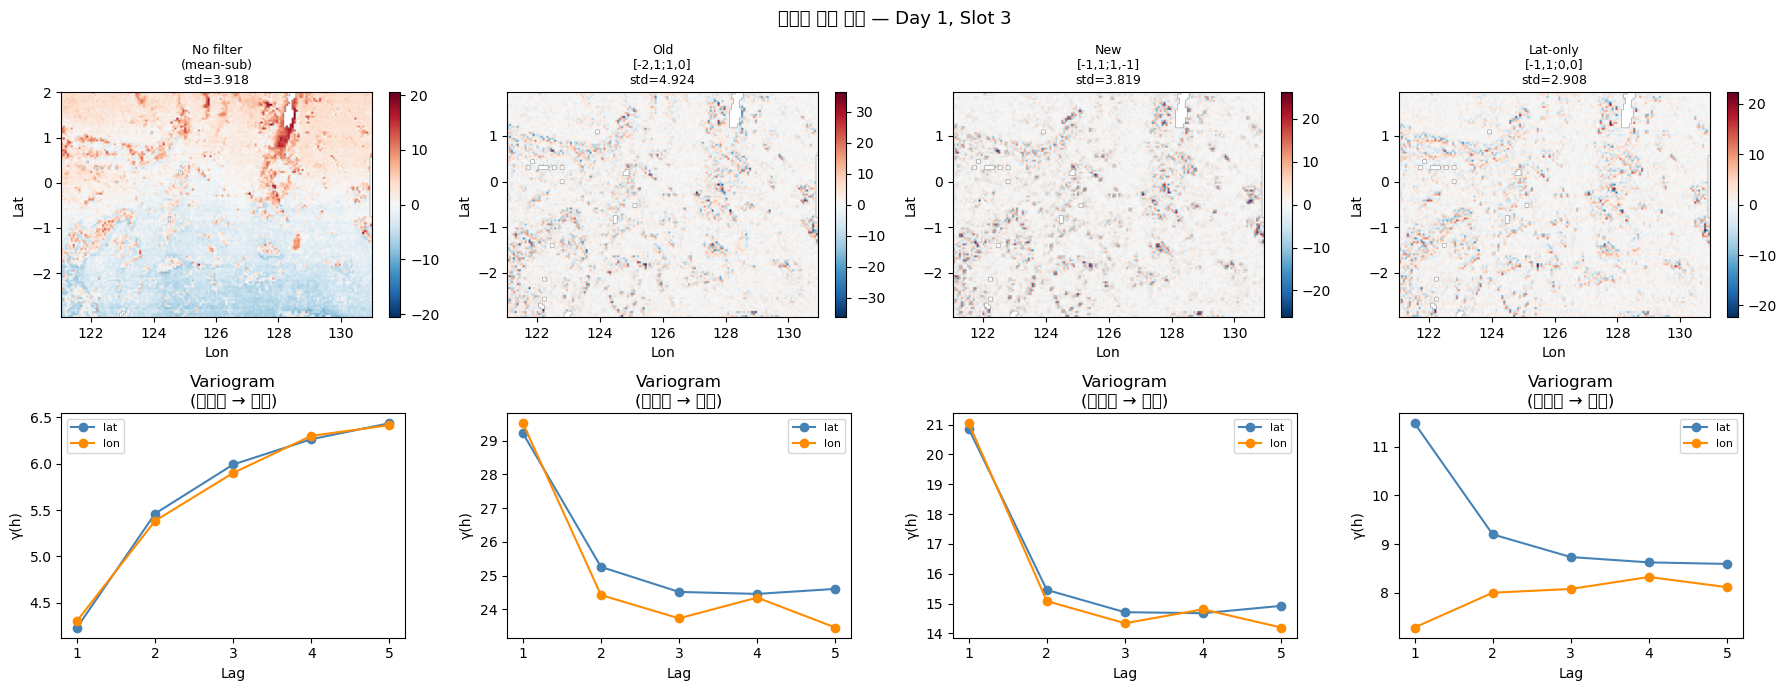

In [7]:
# ── Block 3: 필터 적용 함수들 ─────────────────────────────────────────────────

def apply_2d_filter(grid, kernel):
    """
    grid: (nlat, nlon) numpy array
    kernel: 2×2 numpy array
    Returns filtered grid (nlat-1, nlon-1)
    """
    t = torch.tensor(grid, dtype=torch.float64).unsqueeze(0).unsqueeze(0)
    k = torch.tensor(kernel, dtype=torch.float64).unsqueeze(0).unsqueeze(0)
    result = F.conv2d(t, k, padding='valid').squeeze().numpy()
    return result


kernels = {
    'No filter\n(mean-sub)': None,
    'Old\n[-2,1;1,0]': np.array([[-2., 1.], [1., 0.]]),
    'New\n[-1,1;1,-1]': np.array([[-1., 1.], [1., -1.]]),
    'Lat-only\n[-1,1;0,0]': np.array([[-1., 0.], [1., 0.]]),
}

# 전체 슬롯들에 대해 필터 적용 후 분산 비교
all_slots_raw = []
all_slots_old = []
all_slots_new = []

for slot_i in range(SLOTS_PER_DAY):
    key_s = sorted_keys[DAY_IDX * SLOTS_PER_DAY + slot_i]
    g, _, _ = tensor_to_grid(df_map[key_s])
    g_c = g - np.nanmean(g)   # center
    all_slots_raw.append(g_c[np.isfinite(g_c)].flatten())
    all_slots_old.append(apply_2d_filter(g_c, kernels['Old\n[-2,1;1,0]']).flatten())
    all_slots_new.append(apply_2d_filter(g_c, kernels['New\n[-1,1;1,-1]']).flatten())

var_raw = np.var(np.concatenate(all_slots_raw))
var_old = np.var(np.concatenate(all_slots_old))
var_new = np.var(np.concatenate(all_slots_new))

print(f"분산 비교 (Day {DAY_IDX+1}, 전 슬롯):")
print(f"  Raw (mean-sub): {var_raw:.4f}")
print(f"  Old filter:     {var_old:.4f}  (raw의 {var_old/var_raw*100:.1f}%)")
print(f"  New filter:     {var_new:.4f}  (raw의 {var_new/var_raw*100:.1f}%)")

# 한 슬롯에 대한 상세 시각화
grid_c = grid_raw - np.nanmean(grid_raw)

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
fig.suptitle(f'필터별 결과 비교 — Day {DAY_IDX+1}, Slot {SLOT_IDX}', fontsize=13)

for col, (name, kernel) in enumerate(kernels.items()):
    if kernel is None:
        filtered = grid_c
        show_lats, show_lons = lats, lons
    else:
        filtered = apply_2d_filter(grid_c, kernel)
        show_lats = lats[:-1]  # valid region after filtering
        show_lons = lons[:-1]

    vmax = np.nanmax(np.abs(filtered))

    # 상단: spatial field
    ax = axes[0, col]
    im = ax.imshow(filtered, origin='lower',
                   extent=[show_lons.min(), show_lons.max(), show_lats.min(), show_lats.max()],
                   aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(f'{name}\nstd={np.nanstd(filtered):.3f}', fontsize=9)
    ax.set_xlabel('Lon'); ax.set_ylabel('Lat')
    plt.colorbar(im, ax=ax, fraction=0.046)

    # 하단: variogram
    ax2 = axes[1, col]
    vario = empirical_variogram(filtered)
    for direction, color in [('lat', 'steelblue'), ('lon', 'darkorange')]:
        sub = vario[vario['direction'] == direction]
        if len(sub) > 0:
            ax2.plot(sub['lag'], sub['gamma'], 'o-', color=color, label=direction, markersize=6)
    ax2.set_xlabel('Lag'); ax2.set_ylabel('γ(h)')
    ax2.set_title(f'Variogram\n(안정화 → 정상)')
    ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'diff_filter_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

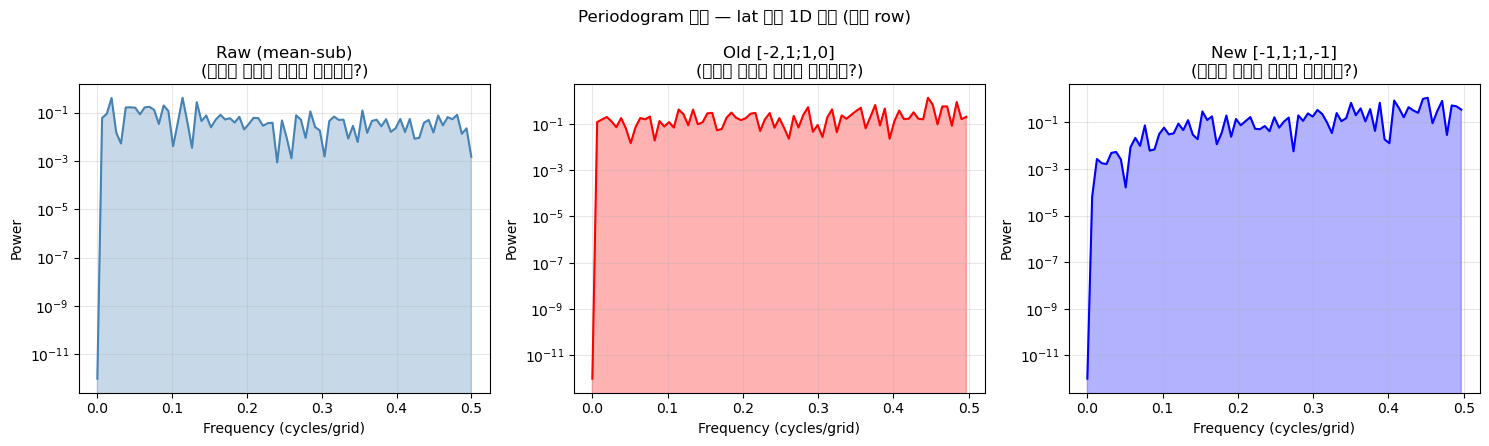

In [8]:
# ── Block 3b: Periodogram 비교 (어떤 주파수가 살아남는가) ──────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Periodogram 비교 — lat 방향 1D 단면 (중앙 row)', fontsize=12)

mid_lat_idx = len(lats) // 2

def row_periodogram(grid, row_idx):
    row = grid[row_idx, :]
    valid = row[np.isfinite(row)]
    if len(valid) < 4:
        return None, None
    f, pxx = periodogram(valid - valid.mean(), scaling='spectrum')
    return f, pxx

plot_data = [
    ('Raw (mean-sub)', grid_c, 'steelblue'),
    ('Old [-2,1;1,0]', apply_2d_filter(grid_c, kernels['Old\n[-2,1;1,0]']), 'red'),
    ('New [-1,1;1,-1]', apply_2d_filter(grid_c, kernels['New\n[-1,1;1,-1]']), 'blue'),
]

for ax_idx, (name, grid_data, color) in enumerate(plot_data):
    ax = axes[ax_idx]
    row_idx = min(mid_lat_idx, grid_data.shape[0] - 1)
    f, pxx = row_periodogram(grid_data, row_idx)
    if f is not None:
        ax.semilogy(f, pxx + 1e-12, color=color, lw=1.5)
        ax.fill_between(f, pxx + 1e-12, alpha=0.3, color=color)
    ax.set_xlabel('Frequency (cycles/grid)')
    ax.set_ylabel('Power')
    ax.set_title(f'{name}\n(저주파 파워가 얼마나 남아있나?)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'diff_periodogram_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Block 4 — 요약 및 대안 방법

### 현재 Old 필터 `[-2,1;1,0]`의 문제점

| 측면 | 설명 |
|---|---|
| 수학적 구조 | $\Delta_{\text{lat}} + \Delta_{\text{lon}}$ — 두 방향 합 (비분리적) |
| 공분산 역산 | $C_{\text{old}}(u) = \sum_{a,b}\sum_{c,d} w_{ab}w_{cd}\, C_X(u + (a-c)\delta_1 + (b-d)\delta_2)$ — 복잡한 cross-term |
| 스펙트럼 | $|H|^2 \approx (\omega_1+\omega_2)^2$ — 대각선 방향만 완전 제거 |
| 위험성 | 공간 상관이 있는 저주파 신호를 일부 보존해서 Whittle 추정에 bias 가능 |

### New 필터 `[-1,1;1,-1]`의 장점

| 측면 | 설명 |
|---|---|
| 수학적 구조 | $\Delta_{\text{lat}} \cdot \Delta_{\text{lon}}$ — **분리 가능(separable)** |
| 공분산 역산 | $C_{\text{new}}(u) = \Delta^2_{\text{lat}}\Delta^2_{\text{lon}} C_X(u)$ — 깔끔한 표현 |
| 스펙트럼 | $|H|^2 = 16\sin^2(\omega_1/2)\sin^2(\omega_2/2)$ — 두 방향 모두 제거 |
| 위험성 | lon-only variation도 완전 제거 → 균일한 lon 추세가 있으면 과다 필터링 |

### 대안: 덜 공격적인 방법들

1. **Mean subtraction only**: 공간 평균만 제거. 추세가 없으면 이걸로 충분
2. **Polynomial detrending**: lat, lon의 1차 또는 2차 회귀 제거 후 Whittle
3. **1D lat diff only**: lon 방향 추세가 없으면 lat만 차분 (분산 덜 감소)
4. **Partial differencing** (분수 차분): long-memory process라면 $d < 0.5$

**결론**: 먼저 Block 2에서 variogram이 안정화되는지 확인.  
- 빠르게 안정화 → 데이터 자체가 거의 정상 → mean subtraction으로 충분  
- 계속 증가 → 비정상 → differencing 필요 → New 필터가 수학적으로 더 깔끔

필터별 분산 감소율 요약 (처음 5일):
  Raw 분산:       16.0779 ± 3.3440
  Old 필터 후:    nan ± nan  (raw의 nan%)
  New 필터 후:    nan ± nan  (raw의 nan%)
  Lat-only 후:    nan ± nan  (raw의 nan%)


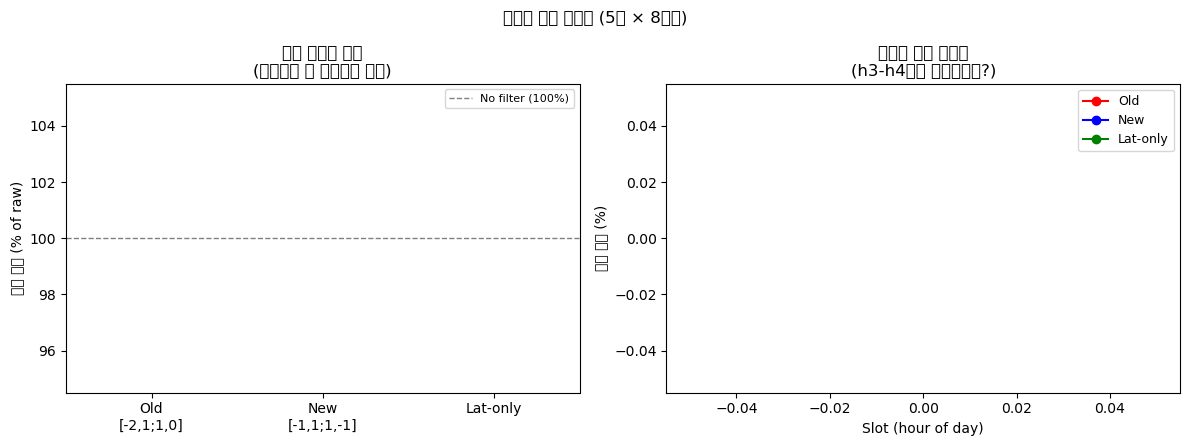


Saved: diff_variance_reduction.csv


In [9]:
# ── Block 4 (fixed): 전체 슬롯 분산 감소율 요약 ──────────────────────────────
# Bug fix: F.conv2d spreads NaN → replace NaN with 0 before filtering,
#          then compute variance on finite values only.
# Also fixed: Lat-only kernel must be 2×1, not 2×2.

import torch.nn.functional as F

def apply_filter_nanfill(grid, kernel_np):
    """
    Apply 2D filter to grid, replacing NaN with 0 before conv2d.
    Returns filtered array with np.nan where input was NaN (edge rows/cols excluded).
    kernel_np: (kH, kW) numpy array.
    """
    nan_mask = ~np.isfinite(grid)
    g_filled = np.where(nan_mask, 0.0, grid)   # NaN → 0 for conv
    t = torch.tensor(g_filled, dtype=torch.float64).unsqueeze(0).unsqueeze(0)
    k = torch.tensor(kernel_np, dtype=torch.float64).unsqueeze(0).unsqueeze(0)
    out = F.conv2d(t, k, padding='valid').squeeze().numpy()
    if out.ndim == 1:
        out = out[np.newaxis, :]
    return out


# Kernels — lat-only must be (2,1), not (2,2)
kernels_fixed = {
    'old':     np.array([[-2., 1.], [1., 0.]]),      # 2×2: output (nlat-1, nlon-1)
    'new':     np.array([[-1., 1.], [1., -1.]]),     # 2×2: output (nlat-1, nlon-1)
    'lat1d':   np.array([[-1.], [1.]]),              # 2×1: output (nlat-1, nlon)
}

results = []

for d_idx in range(min(5, n_days)):
    for slot_i in range(SLOTS_PER_DAY):
        key_s = sorted_keys[d_idx * SLOTS_PER_DAY + slot_i]
        g, _, _ = tensor_to_grid(df_map[key_s])
        g_c = g - np.nanmean(g)
        valid_raw = g_c[np.isfinite(g_c)].flatten()
        if len(valid_raw) < 4:
            continue

        v_raw = np.var(valid_raw)
        row = {'day': d_idx, 'slot': slot_i, 'var_raw': v_raw}

        for name, kern in kernels_fixed.items():
            filt = apply_filter_nanfill(g_c, kern).flatten()
            valid_filt = filt[np.isfinite(filt)]
            v_filt = np.var(valid_filt) if len(valid_filt) > 0 else np.nan
            row[f'var_{name}'] = v_filt
            row[f'pct_{name}'] = v_filt / v_raw * 100 if v_raw > 0 else np.nan

        results.append(row)

df_res = pd.DataFrame(results)

print('필터별 분산 감소율 요약 (처음 5일):')
print(f'  Raw 분산:       {df_res["var_raw"].mean():.4f} ± {df_res["var_raw"].std():.4f}')
for name, label in [('old','Old [-2,1;1,0]'), ('new','New [-1,1;1,-1]'), ('lat1d','Lat-only 1D')]:
    m = df_res[f'pct_{name}'].mean()
    s = df_res[f'pct_{name}'].std()
    print(f'  {label:<20}: raw의 {m:.1f}% ± {s:.1f}%')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('필터별 분산 감소율 (5일 × 8슬롯)', fontsize=12)

ax = axes[0]
bp_data  = [df_res['pct_old'].dropna().values,
             df_res['pct_new'].dropna().values,
             df_res['pct_lat1d'].dropna().values]
bp_labels = ['Old\n[-2,1;1,0]', 'New\n[-1,1;1,-1]', 'Lat-only\n[-1;1]']
ax.boxplot(bp_data, labels=bp_labels, patch_artist=True,
           boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red', lw=2))
ax.axhline(100, ls='--', color='gray', lw=1, label='No filter (100%)')
ax.set_ylabel('분산 비율 (% of raw)')
ax.set_title('분산 감소율 분포\n(낮을수록 더 공격적인 필터)')
ax.legend(fontsize=8)

ax = axes[1]
for col_name, color, label in [
    ('pct_old',   'red',   'Old'),
    ('pct_new',   'blue',  'New'),
    ('pct_lat1d', 'green', 'Lat-only'),
]:
    slot_means = df_res.groupby('slot')[col_name].mean().values
    ax.plot(range(len(slot_means)), slot_means, 'o-', color=color, label=label, markersize=6)
ax.set_xlabel('Slot (hour of day)')
ax.set_ylabel('분산 비율 (%)')
ax.set_title('슬롯별 분산 감소율\n(h3-h4에서 달라지는가?)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'diff_variance_reduction.png', dpi=120, bbox_inches='tight')
plt.show()

df_res.to_csv(OUT_DIR / 'diff_variance_reduction.csv', index=False)
print('Saved: diff_variance_reduction.csv')
